In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# Kernel Restarts
import os
import transformers
import importlib.util

# --- Upgrade pip and ipywidgets early (essential for tqdm & widget-based outputs) --- #
os.system("pip install -q --upgrade pip")
os.system("pip install -q --upgrade ipywidgets")

# --- Helper function to check if a package is installed --- #
def is_installed(pkg_name):
    return importlib.util.find_spec(pkg_name) is not None

# --- Track if restart is needed --- #
restart_needed = False

# Ensure correct Transformers version
if transformers.__version__ != "4.54.1":
    print("⏬ Installing transformers==4.54.1...")
    os.system("pip install transformers==4.54.1 --quiet")
    restart_needed = True

# Remove keras if present
if is_installed("keras"):
    print("🧹 Removing keras (Keras 3.x breaks compatibility)...")
    os.system("pip uninstall -y keras --quiet")
    restart_needed = True

# Install tf-keras (backward-compatible shim)
if not is_installed("tf_keras"):
    print("✅ Installing tf-keras...")
    os.system("pip install tf-keras --quiet")
    restart_needed = True

# Install tensorflow-cpu (lightweight)
if not is_installed("tensorflow"):
    print("📦 Installing tensorflow-cpu...")
    os.system("pip install tensorflow-cpu --quiet")
    restart_needed = True

# Install HuggingFace ecosystem packages
for pkg in ["datasets", "accelerate", "evaluate"]:
    if not is_installed(pkg):
        print(f"📦 Installing {pkg}...")
        os.system(f"pip install {pkg} --quiet")
        restart_needed = True

# Restart the kernel to apply changes
if restart_needed:
    print("🔁 Restarting kernel to apply changes...")
    os.kill(os.getpid(), 9)
else:
    print("✅ All packages already properly installed and configured.")

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏬ Installing transformers==4.54.1...


🧹 Removing keras (Keras 3.x breaks compatibility)...


📦 Installing datasets...


📦 Installing evaluate...


In [2]:
# import os
# import transformers

# if transformers.__version__ != "4.54.1":
#     print("Restart required. Installing correct transformers version...")
#     os.system("pip install transformers==4.54.1 --quiet")
#     os.kill(os.getpid(), 9)  # force kernel restart

In [3]:
import transformers
print(transformers.__version__)

4.54.1


In [4]:
df_models = pd.DataFrame()

In [5]:
# from tqdm.auto import tqdm
# from time import sleep

# for i in tqdm(range(5)):
#     sleep(1)

We shall stick to using the CSV that contains extracted text from **Google's Cloud Vision OCR API**

# T5

## Loading the Model

In [1]:
from transformers import AutoTokenizer, T5ForConditionalGeneration

# Load tokenizer and model (T5, PyTorch version)
tokenizer = AutoTokenizer.from_pretrained('t5-base')
model = T5ForConditionalGeneration.from_pretrained('t5-base')

/usr/local/lib/python3.10/site-packages/torch_xla/__init__.py:251: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(
E0000 00:00:1754374286.348844     258 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:230


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

## Loading and Tokenizing the Dataset

In [3]:
import pandas as pd
filepath = "/kaggle/input/ocr-gsv-pytesseract/gcv-ocr.csv"

df = pd.read_csv(filepath)
df = df[df["text-detected"]!=0]

# print(df["OCR"][0])
# print(len(df)) # 2749

df[["OCR","sentiment"]].to_csv("temp_data.csv", index=False)

In [4]:
root = "/kaggle/working/temp_data.csv"

In [5]:
from datasets import load_dataset
# loading the dataset for sentiment analysis on financial data
# dataset = load_dataset("FinanceInc/auditor_sentiment")


# Load your CSV (replace with your actual file path)
dataset = load_dataset("csv", data_files=root)

# View a sample
print(dataset['train'][0])


# let's take a look at the first entry to get a feel for the data
# dataset['train'][1]

Generating train split: 0 examples [00:00, ? examples/s]

{'OCR': 'STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT', 'sentiment': 'negative'}


In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2749
    })
})

In [7]:
type(dataset['train'])

datasets.arrow_dataset.Dataset

In [8]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
import pandas as pd

# Convert Hugging Face dataset to pandas DataFrame
df = dataset['train'].to_pandas()

# First split: 80% train_val, 20% test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=42
)

# Second split: from train_val_df, get 87.5% train and 12.5% val
# This results in 70/10 train/val overall
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,  # 0.125 * 0.8 = 0.10
    stratify=train_val_df['sentiment'],
    random_state=42
)

# Convert back to Hugging Face Arrow Datasets
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

# Wrap in DatasetDict
final_dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

In [9]:
final_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 1924
    })
    validation: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 275
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [10]:
type(final_dataset)

datasets.dataset_dict.DatasetDict

In [11]:
print(final_dataset['validation'].to_pandas())

                                                   OCR sentiment
0                                 THIS BIKE\nPROVES IT   neutral
1    Never give up.\nGreat things\ntake time.\nBe p...  positive
2    INDIA\nTODAY\nTHANE BUILDING\nCOLLAPSE\n10 DEA...  negative
3    Don't lose hope, you never know\nwhat tomorrow...  positive
4                                        KERALA FLOODS  negative
..                                                 ...       ...
270  WALL COLLAPSED,\n9 PEOPLE DIED IN LUCKNOW\nOne...  negative
271  ALMOST\n10%\n•\nOF THE\nPEOPLE\nIN FRANCE AGED...   neutral
272                     DEATH TOLL CROSSES 1 LAKH MARK  negative
273  when you write 10\nlines of code without\nsear...  positive
274  Shayarisove\nSmile, smile at your mind as\noft...  positive

[275 rows x 2 columns]


In [12]:
# # defining a function to tokenize the sentences
# def tokenize_function(example):
#     return tokenizer(
#         example['OCR'],
#         # padding sentences to the maximum length for consistent input size
#         padding='max_length',
#         # truncating sentences to fit within the model's expected input length
#         truncation=True,
#         # returning attention masks to let the model know which tokens are padding
#         return_attention_mask=True,
#         max_length = 128 # (default if set to 1024)
#     )

# # applying the tokenization function to the entire dataset in batches
# tokenized_dataset = final_dataset.map(tokenize_function, batched=True)


def tokenize_function(example):
    # Format input and target strings
    inputs = ["sentiment analysis: " + ocr for ocr in example['OCR']]
    targets = example['sentiment']  # already text: "positive", etc.

    # Tokenize inputs and targets
    model_inputs = tokenizer(
        inputs,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_attention_mask=True
    )

    # Tokenize targets as labels
    labels = tokenizer(
        targets,
        padding="max_length",
        truncation=True,
        max_length=10  # sentiment words are short
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


tokenized_dataset = final_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Map:   0%|          | 0/275 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

In [13]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1924
    })
    validation: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 275
    })
    test: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 550
    })
})

In [14]:
tokenized_dataset["train"]["attention_mask"]

Column([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Preparing for Training

In [15]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

# -------------------------- TRAINING DATALOADER ---------------------------------------------------


# Convert tokenized dataset to pandas
df_train = tokenized_dataset['train'].to_pandas()

# Extract inputs
X_train_inputs = np.array(df_train['input_ids'].tolist())
X_train_attention = np.array(df_train['attention_mask'].tolist())
y_train = np.array(df_train['labels'].tolist())  # already tokenized label IDs

# Convert to tensors
train_inputs = torch.tensor(X_train_inputs, dtype=torch.long)
train_attention = torch.tensor(X_train_attention, dtype=torch.long)
train_labels = torch.tensor(y_train, dtype=torch.long)

# Create TensorDataset
train_data = TensorDataset(train_inputs, train_attention, train_labels)

# DataLoader
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)



# -------------------------- TRAINING DATALOADER ---------------------------------------------------
df_val = tokenized_dataset['validation'].to_pandas()
X_val_inputs = np.array(df_val['input_ids'].tolist())
X_val_attention = np.array(df_val['attention_mask'].tolist())
y_val = np.array(df_val['labels'].tolist())

val_inputs = torch.tensor(X_val_inputs, dtype=torch.long)
val_attention = torch.tensor(X_val_attention, dtype=torch.long)
val_labels = torch.tensor(y_val, dtype=torch.long)

val_data = TensorDataset(val_inputs, val_attention, val_labels)
val_dataloader = DataLoader(val_data, batch_size=16, shuffle=False)

In [16]:
list(df_train['input_ids'])[0]

array([ 6493,  1693,    10,     3,  8727,  5080,   439,   283,   476,
         382,  6299, 20151,   476,     1,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0]

In [17]:
df_train

,OCR,sentiment,input_ids,attention_mask,labels
0,GREEK\nMYTHOLOGY,neutral,"[6493, 1693, 10, 3, 8727, 5080, 439, 283, 476,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...","[7163, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1,The Call-Chronicle-Examiner\nEARTHQUAKE AND FI...,negative,"[6493, 1693, 10, 37, 2571, 18, 3541, 18074, 24...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
2,"""May the festival of colours\nbrings the brigh...",positive,"[6493, 1693, 10, 96, 15881, 8, 3994, 13, 6548,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1465, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
3,for\nOXFORD\nSTUNNED BY\nTEEN'S DEATH,negative,"[6493, 1693, 10, 21, 411, 4, 371, 18400, 5097,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
4,"August 23rd, 2011\nVirginia earthquake",negative,"[6493, 1693, 10, 1660, 1902, 52, 26, 6, 2722, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...
1919,"MIND JOURNAL\n""What is Pain?""\nThe moment when...",negative,"[6493, 1693, 10, 283, 13885, 446, 9131, 567, 4...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2841, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1920,Veritasium\nVeritasium\nVeri\nVaritasi\nritasi...,neutral,"[6493, 1693, 10, 781, 155, 9, 7, 2552, 781, 15...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[7163, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1921,You only\nfail when\n@Meltblogs\nyou stop\ntry...,positive,"[6493, 1693, 10, 148, 163, 5124, 116, 3320, 32...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1465, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
1922,You must teach\nyour heart to accept\nwhat can...,positive,"[6493, 1693, 10, 148, 398, 3884, 39, 842, 12, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1465, 1, 0, 0, 0, 0, 0, 0, 0, 0]"


In [19]:
# true_text_labels = df_test['sentiment'].tolist()  # For later decoding/evaluation

## Training the Model

In [20]:
import torch
from torch.optim import AdamW
from transformers import get_scheduler
from torch.cuda.amp import autocast, GradScaler

# 1. Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Optimizer with weight decay grouping (recommended for T5)
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=5e-5)

# 3. Learning rate scheduler
num_epochs = 3
num_training_steps = len(train_dataloader) * num_epochs

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# 4. Mixed precision scaler (for AMP)
scaler = GradScaler()

# 5. Loss function is already handled inside T5 — just pass labels

/tmp/ipykernel_258/2959609429.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [21]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import copy

# === Settings ===
epochs = 10
patience = 3
min_delta = 1e-4
grad_clip_value = 1.0

# === Tracking ===
train_losses = []
val_losses = []
opt_train_loss = 0
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

scaler = torch.cuda.amp.GradScaler()  # For mixed precision

for epoch in range(epochs):
    # === Training ===
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1} - Training"):
        b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():  # Mixed Precision
            outputs = model(input_ids=b_input_ids,
                            attention_mask=b_attention_mask,
                            labels=b_labels)
            loss = outputs.loss

        total_train_loss += loss.item()

        scaler.scale(loss).backward()

        # Gradient Clipping (recommended for T5)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_value)

        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # === Validation ===
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Epoch {epoch+1} - Validation"):
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]

            with torch.cuda.amp.autocast():
                outputs = model(input_ids=b_input_ids,
                                attention_mask=b_attention_mask,
                                labels=b_labels)
                val_loss = outputs.loss
                total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch + 1}:")
    print(f"  ➤ Avg Training Loss    = {avg_train_loss:.4f}")
    print(f"  ➤ Avg Validation Loss  = {avg_val_loss:.4f}")

    # === Early Stopping Logic ===
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        opt_train_loss = avg_train_loss
        epochs_no_improve = 0
        print("  ✅ Validation loss improved — saving best model.")
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ No improvement in validation loss ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"\n⏹️ Early stopping triggered after {epoch + 1} epochs.")
            break

# === Load the Best Model Back ===
if best_model_state:
    model.load_state_dict(best_model_state)
    print("\n✅ Best model weights restored.")

/tmp/ipykernel_258/4021802025.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # For mixed precision
Epoch 1 - Training:   0%|          | 0/121 [00:00<?, ?it/s]/tmp/ipykernel_258/4021802025.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Mixed Precision
Epoch 1 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]/tmp/ipykernel_258/4021802025.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.18it/s]



Epoch 1:
  ➤ Avg Training Loss    = 1.3843
  ➤ Avg Validation Loss  = 0.0511
  ✅ Validation loss improved — saving best model.


Epoch 2 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.17it/s]



Epoch 2:
  ➤ Avg Training Loss    = 0.0510
  ➤ Avg Validation Loss  = 0.0390
  ✅ Validation loss improved — saving best model.


Epoch 3 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.21it/s]


...


Epoch 4:
  ➤ Avg Training Loss    = 0.0359
  ➤ Avg Validation Loss  = 0.0385
  ⚠️ No improvement in validation loss (1/3)


Epoch 5 - Validation: 100%|██████████| 18/18 [00:06<00:00,  2.66it/s]



Epoch 5:
  ➤ Avg Training Loss    = 0.0377
  ➤ Avg Validation Loss  = 0.0385
  ⚠️ No improvement in validation loss (2/3)


Epoch 6 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.16it/s]



Epoch 6:
  ➤ Avg Training Loss    = 0.0348
  ➤ Avg Validation Loss  = 0.0385
  ⚠️ No improvement in validation loss (3/3)

⏹️ Early stopping triggered after 6 epochs.

✅ Best model weights restored.


In [24]:
if best_model_state:
    # model.load_state_dict(best_model_state)
    # print("\n✅ Best model weights restored.")

    # Save the best model
    save_path = "T5__best_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"✅ Best model saved to {save_path}")

✅ Best model saved to T5__best_model.pt


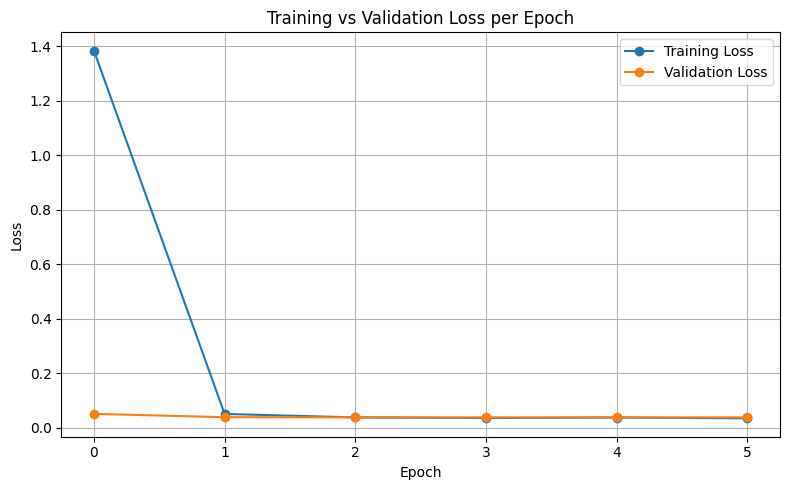

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("T5__loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# epochs = 3
# for epoch in tqdm(range(epochs)):
#     model.train()
#     total_loss = 0
#     for batch in train_dataloader:
#         b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
#         # resetting gradients before backpropagation
#         model.zero_grad()
#         # performing a forward pass to calculate outputs
#         outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
#         # calculating the loss 
#         loss = outputs.loss
#         total_loss += loss.item()
#         # backpropagating the loss to compute gradients
#         loss.backward()
#         # updating model parameters using the computed gradients
#         optimizer.step()
#     avg_train_loss = total_loss / len(train_dataloader)
#     print(f"Epoch {epoch + 1}, Average Training Loss: {avg_train_loss:.4f}")

## Making predictions

In [28]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1924
    })
    validation: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 275
    })
    test: Dataset({
        features: ['OCR', 'sentiment', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 550
    })
})

In [29]:
# Convert the tokenized test dataset to pandas
df_test = tokenized_dataset['test'].to_pandas()

# Extract tokenized inputs and labels
X_test_inputs = np.array(df_test['input_ids'].tolist())
X_test_attention = np.array(df_test['attention_mask'].tolist())
y_test = np.array(df_test['labels'].tolist())  # ✅ these are already tokenized label IDs

# Convert to PyTorch tensors
test_inputs = torch.tensor(X_test_inputs, dtype=torch.long)
test_attention = torch.tensor(X_test_attention, dtype=torch.long)
test_labels = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset and DataLoader
test_data = TensorDataset(test_inputs, test_attention, test_labels)
test_dataloader = DataLoader(test_data, batch_size=16)

In [30]:
def get_predictions(model, dataloader, tokenizer, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]

            # Generate predictions using greedy decoding
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=10
            )

            # Decode generated tokens to strings
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

            predictions.extend(decoded_preds)
            true_labels.extend(decoded_labels)

    return predictions, true_labels


baseline_predictions, true_labels = get_predictions(model, test_dataloader, tokenizer, device)

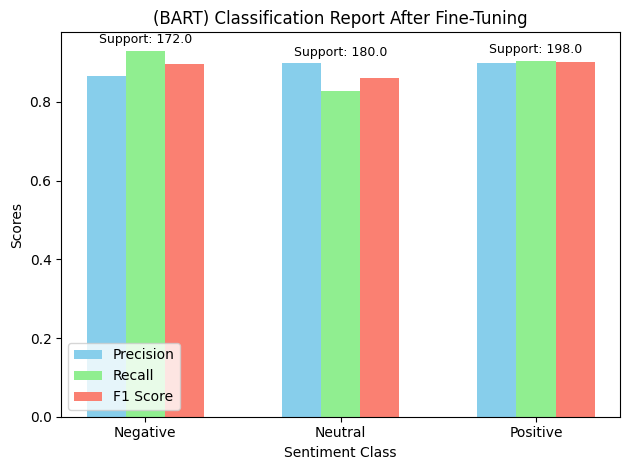

In [31]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(true_labels, baseline_predictions, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]
support = [report[label]['support'] for label in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1_score, width, label='F1 Score', color='salmon')

ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Scores')
ax.set_title('(BART) Classification Report After Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i in range(len(support)):
    ax.text(i, max(precision[i], recall[i], f1_score[i]) + 0.02, f'Support: {support[i]}', ha='center', fontsize=9)

ax.grid(False)

fig.tight_layout()
plt.show()

In [32]:
print(report['accuracy'])

0.8872727272727273


In [36]:
import os
import pandas as pd

filepath = "/kaggle/working/tsa_model_expt_results.csv"

# Model results as a dict
df_model = {
    "Name": "T5",
    "Training Loss": opt_train_loss,
    "Validation Loss": best_val_loss,
    "Accuracy": report['accuracy']
}

# Convert to DataFrame
df_model = pd.DataFrame([df_model])  # Note the brackets to make it a list of dicts

# If file exists, append to it
if os.path.exists(filepath):
    results = pd.read_csv(filepath)
    results = pd.concat([results, df_model], ignore_index=True)
else:
    results = df_model  # Start a new DataFrame

# Save the updated DataFrame back to CSV
# print(results)
results.to_csv(filepath, index=False)

In [39]:
results = results.drop(columns=['Unnamed: 0'])

In [40]:
# df_models = pd.DataFrame(df_models)
results.to_csv("tsa_model_expt_results.csv", index=False)

In [41]:
results

,Name,Training Loss,Validation Loss,Accuracy
0,BART,0.148998,0.193558,0.909091
1,RoBERTa,0.081400,0.406700,0.941800
2,T5,0.038137,0.038477,0.887273
